In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


ModuleNotFoundError: No module named 'seaborn'

In [10]:
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [18]:
df['Classes'] = np.where(df['Classes'].str.contains("not fire"),0,1)

In [20]:
df.drop(['day','month','year'],axis=1,inplace=True)
df.head()

KeyError: "['day', 'month', 'year'] not found in axis"

In [21]:
x=df.drop('FWI',axis=1)

In [22]:
y=df['FWI']

In [23]:
x.head()

,Unnamed: 0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [24]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [25]:
x_train.shape

(181, 12)

<Axes: >

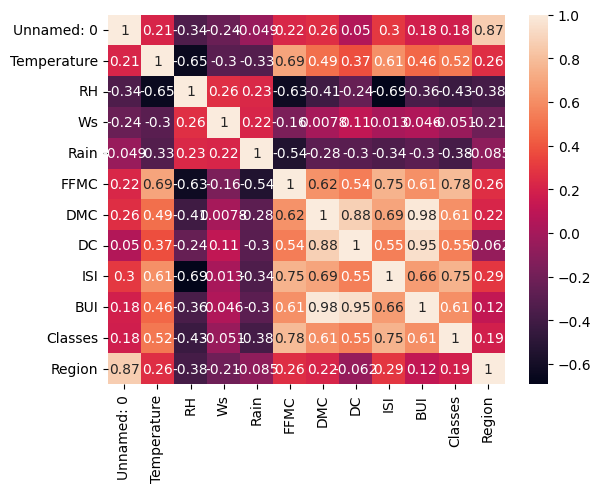

In [27]:
plt.Figure(figsize=(23,10))
corr = x_train.corr()
sns.heatmap(corr,annot=True)

In [ ]:
##drop kar dena hai jo multicolineartiy aur jo threshold se jyda hao multicolinearityi chech krana ka code copy me likha hai
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr


In [30]:
##feature Scalinf or standerdrization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [31]:
x_train_scaled

array([[-0.32646157, -0.84344696,  0.75856688, ..., -0.75869701,
        -1.07459849, -0.96204569],
       [ 0.30999864, -0.03712355, -0.5214682 , ..., -0.57849977,
         0.93058013,  1.03945167],
       [ 1.59738408, -0.84344696, -1.46465194, ...,  0.85614749,
         0.93058013,  1.03945167],
       ...,
       [-0.3987866 , -1.91854483,  0.89330741, ..., -1.02206221,
        -1.07459849, -0.96204569],
       [ 0.85966883,  1.03797433, -0.45409793, ...,  0.50268367,
         0.93058013,  1.03945167],
       [-0.25413655, -0.57467249,  0.96067768, ..., -0.98047823,
        -1.07459849, -0.96204569]], shape=(181, 12))

In [ ]:
!pip install sk

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
linearreg = LinearRegression()
linearreg.fit(x_train_scaled,y_train)
y_prediction= linearreg.predict(x_test)
mae = mean_absolute_error(y_test,y_prediction)
score = r2_score(y_test,y_prediction)
print("mae : ",mae)
print("R2 SCORE : ",r2_score)

mae :  35.97254274914582
R2 SCORE :  <function r2_score at 0x000001CEDC2A3920>


c:\Users\visha\OneDrive\Desktop\varun\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


mae :  1.1215966856268877
R2 SCORE :  <function r2_score at 0x000001CEDC2A3920>


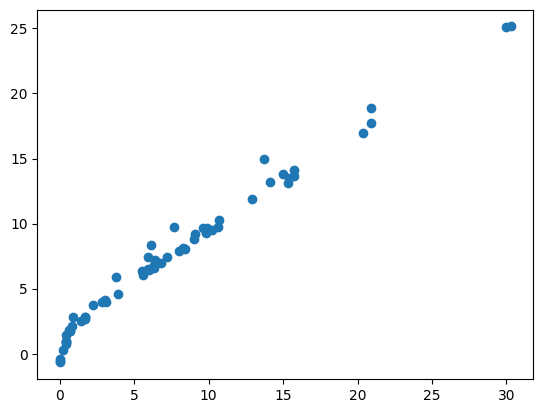

In [33]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
Lasso = Lasso()
Lasso.fit(x_train_scaled,y_train)
y_prediction= Lasso.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_prediction)
score = r2_score(y_test,y_prediction)
print("mae : ",mae)
print("R2 SCORE : ",r2_score)
plt.scatter(y_test,y_prediction)

mae :  0.6010382960657193
R2 SCORE :  <function r2_score at 0x000001CEDC2A3920>


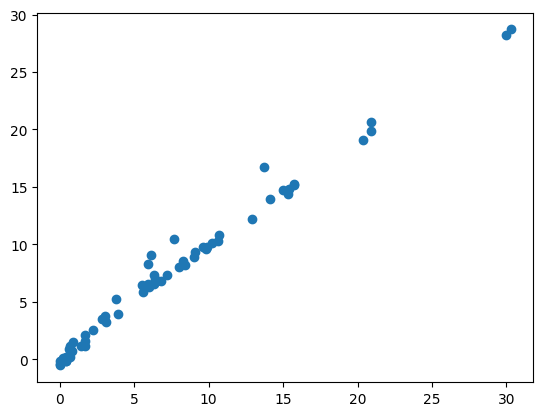

In [35]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
Ridge = Ridge()
Ridge.fit(x_train_scaled,y_train)
y_prediction= Ridge.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_prediction)
score = r2_score(y_test,y_prediction)
print("mae : ",mae)
print("R2 SCORE : ",r2_score)
plt.scatter(y_test,y_prediction)

In [36]:
import pickle
pickle.dump(Ridge,open('Ridge.pkl','wb'))
pickle.dump(Lasso,open('Lasso.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))
